# --- Model(s) Evaluation ---

In [1]:
#> --- Imports ---
import sys
import numpy as np
import sys
from pathlib import Path
# --- Resolving Package Path ---
notebook_dir = Path.cwd()
src_path = (notebook_dir / ".." / "src").resolve()
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
# --- Importing API Files ---
from random_forest.forest import RandomForest
from random_forest.metrics import model_evaluator
from random_forest.plot import model_metrics_plotter

In [2]:
help(RandomForest.load_model)

Help on method load_model in module random_forest.forest.forest:

load_model(directory='..//artifacts//random_forest//', silent_load=False) class method of random_forest.forest.forest.RandomForest
    #> Usage and Information
    Use this function to load a saved the RF model.

    #> Parameters Documentation:
    1. directory: Path to desired directory which the model will be saved in.
    2. silent_load: Silent's the "Successful Loading" message.



In [3]:
help(model_evaluator)

Help on function model_evaluator in module random_forest.metrics.metrics:

model_evaluator(
    predicted_y,
    y_test,
    RFModel=None,
    silent=False,
    save=False,
    text_file_name='metrics.txt',
    save_path='..\\\\results\\\\benchmarks\\\\'
)
    #> Usage and Information
    Use this function to evalate RF model and create a "metrics.txt" to save the evaluation info.

    #> Parameters Documentation:
    1. predicted_y: RF model predicted y.
    2. y_test: y_test array.
    3. silent: Flag for printing the results.
    4. save: Flag for saving the results as ".txt" file.
    5. text_file_name: Name for saved ".txt" file.
    6. save_path: Save path for ".txt" file.



In [4]:
help(model_metrics_plotter)

Help on function model_metrics_plotter in module random_forest.plot.plotter:

model_metrics_plotter(
    metrics_foler_path='..\\\\results\\\\benchmarks\\\\',
    save_plot=True,
    save_to='..\\\\results\\\\figures\\\\'
)
    #> Usage and Information
    Use this function to turn "metrics.txt"(s) into comparetive figures.

    #> Parameters Documentation:
    1. metrics_foler_path: Path to "metrics.txt".
    2. save_plot: Flag for saving the plot.
    3. save_to: Save path for the plotted figure.



In [5]:
# --- Loading Test Data ---
y_test = np.load(r"..\\data\\splits\\transactions\\y_test.npy")
# --- Evaluation Loop ---
for i in range(6):
    # --- Lodaing Model ---
    RandomForestModel = RandomForest.load_model(directory=f"..\\artifacts\\random_forest\\transactions\\config_{i+1}\\", silent_load=True)
    # --- Loading The Predictions ---
    predicted_y = np.load(f"..\\artifacts\\predictions\\transactions\\config_{i+1}\\predicted_y.npy")
    # --- Evaluating ---
    model_evaluator(predicted_y, y_test,
                    RFModel=RandomForestModel,
                    silent=True,
                    save=True, 
                    text_file_name=f"config_{i+1}.txt", 
                    save_path=r"..\\results\\benchmarks\\")

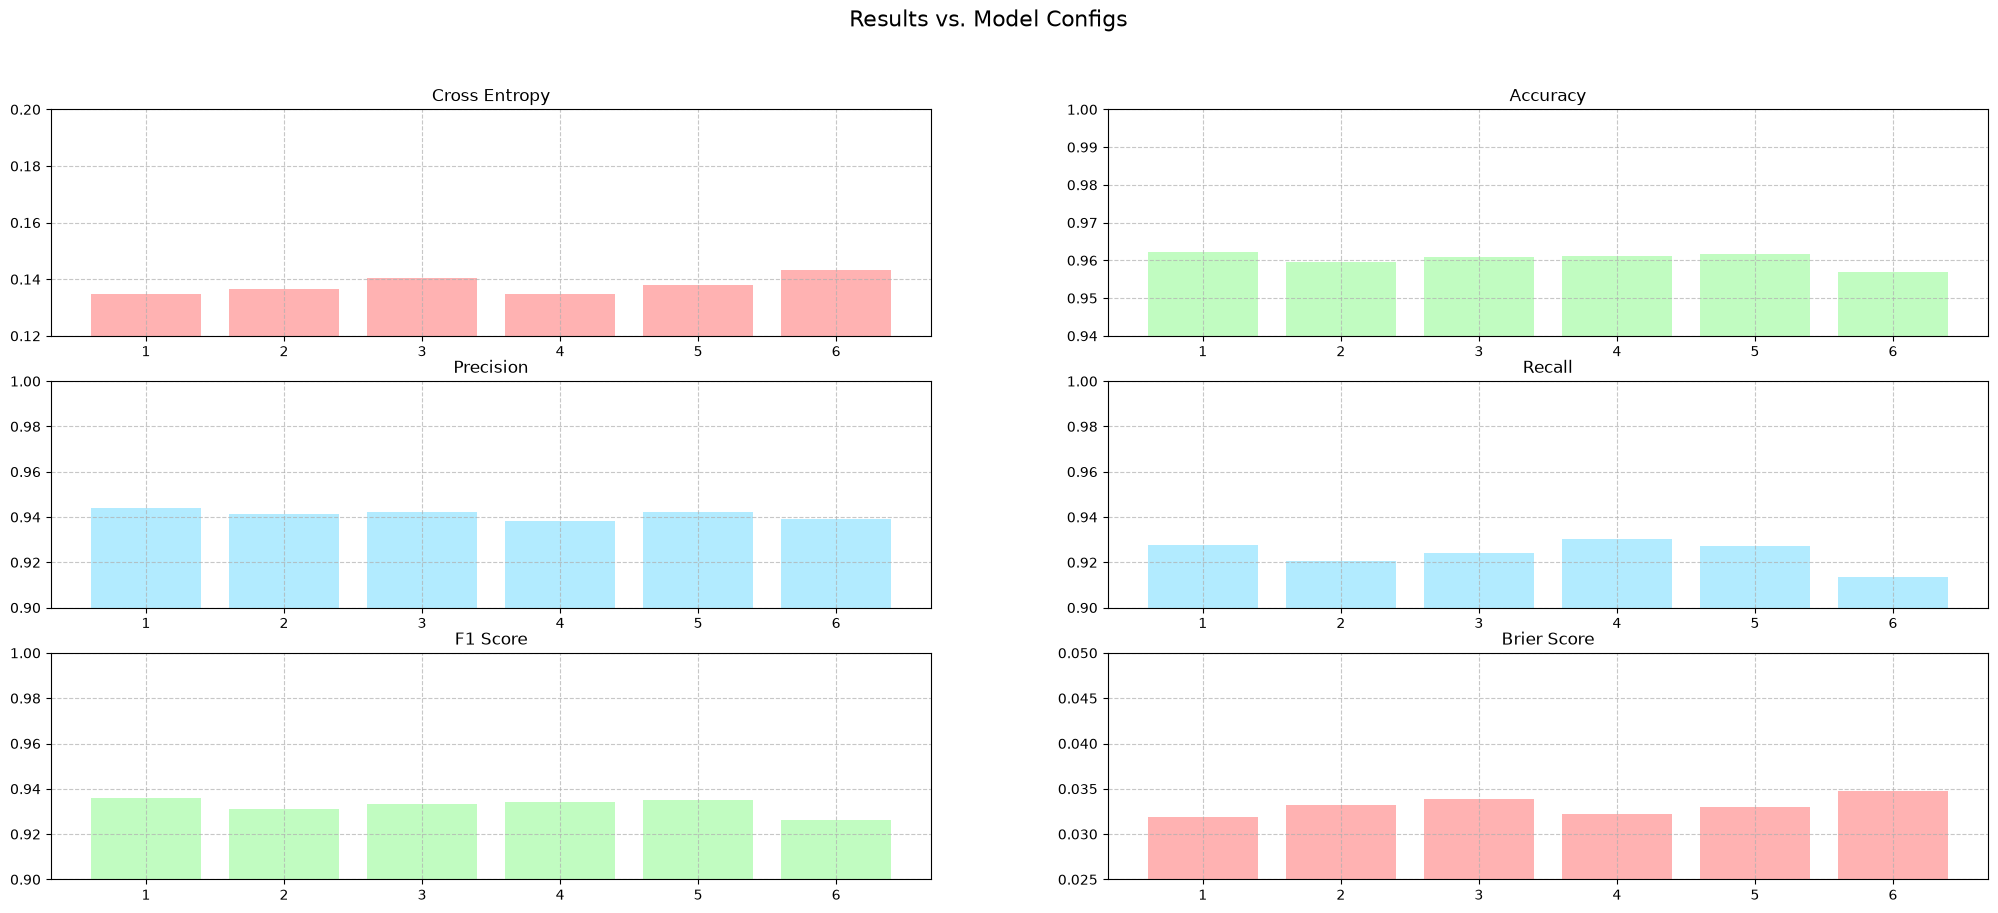

In [6]:
# --- Plotting ---
model_metrics_plotter(metrics_foler_path = r"..\\results\\benchmarks\\", 
                          save_plot = True, 
                          save_to = r"..\\results\\figures\\")